# Student Dropout Prediction — Exploratory Data Analysis

This notebook performs exploratory data analysis for the student dropout prediction project. The analysis focuses on Graduate and Dropout records and excludes academic-related features to align with the early non-academic prediction objective.

## Import Library

In [239]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

### Check Path and Dataset Existence

In [ ]:
current_path = Path.cwd()

if (current_path / "data" / "raw" / "dataset.csv").exists():
    PROJECT_ROOT = current_path
else:
    PROJECT_ROOT = current_path.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "dataset.csv"

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())

Project root: c:\Not Default\Projects\student-dropout-prediction-ml
Dataset path: c:\Not Default\Projects\student-dropout-prediction-ml\data\raw\dataset.csv
Dataset exists: True


### Load Dataset

In [241]:
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (4424, 35)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


### Raw Data Shape

In [242]:
print("Raw dataset shape:", df.shape)
print("Raw duplicate rows:", df.duplicated().sum())
print("Raw missing values:", df.isnull().sum().sum())

Raw dataset shape: (4424, 35)
Raw duplicate rows: 0
Raw missing values: 0


### Remove Academic Features for EDA Scope

Since this project focuses on early non-academic dropout prediction, academic-related features are excluded from the EDA subset. This includes semester-based academic performance features and, if available, academic grade features.

In [243]:
academic_semester_features = [
    col for col in df.columns
    if "Curricular units" in col
]

academic_grade_features = [
    "Admission grade",
    "Previous qualification (grade)"
]

academic_grade_features = [
    col for col in academic_grade_features
    if col in df.columns
]

academic_features = academic_semester_features + academic_grade_features

print("Original dataset shape before removing academic features:", df.shape)

df_non_acad = df.drop(columns=academic_features).copy()

print("EDA dataset shape after removing academic features:", df_non_acad.shape)
print("Removed academic features:", len(academic_features))

academic_features

Original dataset shape before removing academic features: (4424, 35)
EDA dataset shape after removing academic features: (4424, 23)
Removed academic features: 12


['Curricular units 1st sem (credited)',
 'Curricular units 1st sem (enrolled)',
 'Curricular units 1st sem (evaluations)',
 'Curricular units 1st sem (approved)',
 'Curricular units 1st sem (grade)',
 'Curricular units 1st sem (without evaluations)',
 'Curricular units 2nd sem (credited)',
 'Curricular units 2nd sem (enrolled)',
 'Curricular units 2nd sem (evaluations)',
 'Curricular units 2nd sem (approved)',
 'Curricular units 2nd sem (grade)',
 'Curricular units 2nd sem (without evaluations)']

### Create Dropout-Graduate EDA Subset

The original target contains three classes: Dropout, Enrolled, and Graduate.

Since this project focuses on binary dropout prediction, Enrolled records are excluded from the EDA subset. The target is not encoded into 0 and 1 in this notebook because encoding will be handled later in the preprocessing stage.

In [244]:
df_binary = df_non_acad[df_non_acad["Target"] != "Enrolled"].copy()

print("EDA dataset shape before removing Enrolled:", df_non_acad.shape)
print("EDA dataset shape after removing Enrolled:", df_binary.shape)
print("Removed Enrolled rows:", df_non_acad.shape[0] - df_binary.shape[0])

df_binary["Target"].value_counts()

EDA dataset shape before removing Enrolled: (4424, 23)
EDA dataset shape after removing Enrolled: (3630, 23)
Removed Enrolled rows: 794


Target
Graduate    2209
Dropout     1421
Name: count, dtype: int64

## EDA

### Non-graphical EDA

#### Dataset Info

In [245]:
df_binary.info()

<class 'pandas.DataFrame'>
Index: 3630 entries, 0 to 4423
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Marital status              3630 non-null   int64  
 1   Application mode            3630 non-null   int64  
 2   Application order           3630 non-null   int64  
 3   Course                      3630 non-null   int64  
 4   Daytime/evening attendance  3630 non-null   int64  
 5   Previous qualification      3630 non-null   int64  
 6   Nacionality                 3630 non-null   int64  
 7   Mother's qualification      3630 non-null   int64  
 8   Father's qualification      3630 non-null   int64  
 9   Mother's occupation         3630 non-null   int64  
 10  Father's occupation         3630 non-null   int64  
 11  Displaced                   3630 non-null   int64  
 12  Educational special needs   3630 non-null   int64  
 13  Debtor                      3630 non-null   int64

#### Check Column List

In [246]:
df_binary.columns.tolist()

['Marital status',
 'Application mode',
 'Application order',
 'Course',
 'Daytime/evening attendance',
 'Previous qualification',
 'Nacionality',
 "Mother's qualification",
 "Father's qualification",
 "Mother's occupation",
 "Father's occupation",
 'Displaced',
 'Educational special needs',
 'Debtor',
 'Tuition fees up to date',
 'Gender',
 'Scholarship holder',
 'Age at enrollment',
 'International',
 'Unemployment rate',
 'Inflation rate',
 'GDP',
 'Target']

#### Check Duplicate Rows
After removing academic-related features, several rows become duplicated because some records only differed in the removed academic columns. These duplicated rows are kept during EDA and will be reviewed again during preprocessing.

In [247]:
duplicate_count = df_binary.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 4


#### Check Missing Values

In [248]:
missing_values = df_binary.isnull().sum().sort_values(ascending=False)

print("Total missing values:", missing_values.sum())

missing_values[missing_values > 0]

Total missing values: 0


Series([], dtype: int64)

#### Feature Type Checking

Several columns in the dataset are stored as numbers, but not all numerical-looking columns should be treated as continuous variables.

In this EDA, features are separated based on domain understanding:

- Continuous features are variables with meaningful numerical magnitude, such as age and macroeconomic indicators.
- Categorical-like features are variables represented by numerical codes, such as gender, course, application mode, and parental occupation.

This separation is important because continuous features are more suitable for descriptive statistics, histograms, boxplots, and correlation analysis, while categorical-like features are more suitable for countplots and cross-tabulation.

In [249]:
continuous_features = [
    "Age at enrollment",
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]

continuous_features = [
    col for col in continuous_features
    if col in df_binary.columns
]

categorical_like_features = [
    col for col in df_binary.columns
    if col not in continuous_features and col != "Target"
]

print("Continuous features:", len(continuous_features))
print(continuous_features)

print("\nCategorical-like features:", len(categorical_like_features))
print(categorical_like_features)

Continuous features: 4
['Age at enrollment', 'Unemployment rate', 'Inflation rate', 'GDP']

Categorical-like features: 18
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']


#### Check Continuous Feature Statistics

In [250]:
df_binary[continuous_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Age at enrollment,3630.0,23.461157,7.827994,17.00,19.0,20.00,25.00,70.00
Unemployment rate,3630.0,11.630358,2.667652,7.60,9.4,11.10,13.90,16.20
Inflation rate,3630.0,1.231598,1.384911,-0.80,0.3,1.40,2.60,3.70
GDP,3630.0,-0.009256,2.259986,-4.06,-1.7,0.32,1.79,3.51


#### Crosstab

In [251]:
selected_categorical_features = [
    col for col in categorical_like_features
    if df_binary[col].nunique() <= 7
]

print("Selected categorical features:", len(selected_categorical_features))
selected_categorical_features

Selected categorical features: 10


['Marital status',
 'Application order',
 'Daytime/evening attendance',
 'Displaced',
 'Educational special needs',
 'Debtor',
 'Tuition fees up to date',
 'Gender',
 'Scholarship holder',
 'International']

In [252]:
for col in selected_categorical_features:
    print(f"\nCrosstab: {col} vs Target")
    display(
        pd.crosstab(
            df_binary[col],
            df_binary["Target"],
            normalize="index"
        ).round(3) * 100
    )


Crosstab: Marital status vs Target


Target,Dropout,Graduate
Marital status,,
1,37.0,63.0
2,54.7,45.3
3,50.0,50.0
4,56.0,44.0
5,50.0,50.0
6,80.0,20.0



Crosstab: Application order vs Target


Target,Dropout,Graduate
Application order,,
0,0.0,100.0
1,42.8,57.2
2,33.3,66.7
3,30.5,69.5
4,26.6,73.4
5,41.1,58.9
6,25.6,74.4



Crosstab: Daytime/evening attendance vs Target


...

Target,Dropout,Graduate
Gender,,
0,30.2,69.8
1,56.1,43.9



Crosstab: Scholarship holder vs Target


Target,Dropout,Graduate
Scholarship holder,,
0,48.4,51.6
1,13.8,86.2



Crosstab: International vs Target


Target,Dropout,Graduate
International,,
0,39.2,60.8
1,37.2,62.8


### Graphical EDA

#### Target Percentage Distribution Visualization

This section visualizes the distribution of Graduate and Dropout classes after removing Enrolled records. This is done because the final project focuses on binary dropout prediction.

In [253]:
target_percentage = (
    df_binary["Target"]
    .value_counts(normalize=True)
    .loc[["Graduate", "Dropout"]]
    * 100
)

target_percentage_table = pd.DataFrame({
    "percentage": target_percentage.round(2)
})

target_percentage_table

,percentage
Target,
Graduate,60.85
Dropout,39.15


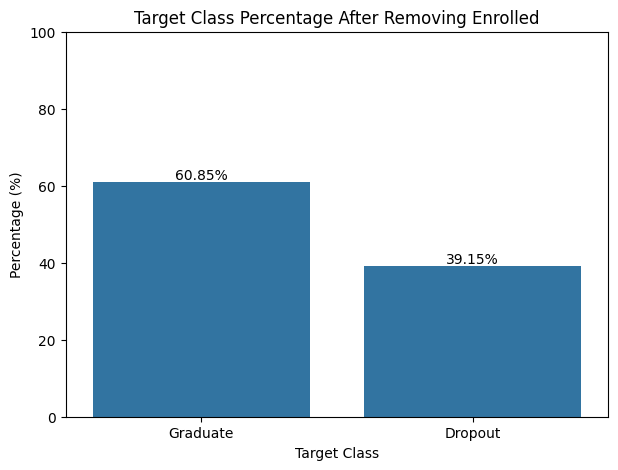

In [254]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=target_percentage.index,
    y=target_percentage.values
)

plt.title("Target Class Percentage After Removing Enrolled")
plt.xlabel("Target Class")
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.show()

##### Target Distribution Insight

After removing Enrolled records, the dataset contains only Graduate and Dropout classes.  
The Graduate class is larger than the Dropout class, which indicates a moderate class imbalance.

This means that accuracy alone may not be enough for model evaluation later.  
Metrics such as precision, recall, F1-score, ROC-AUC, and confusion matrix should also be used.

#### Continuous Features Histogram

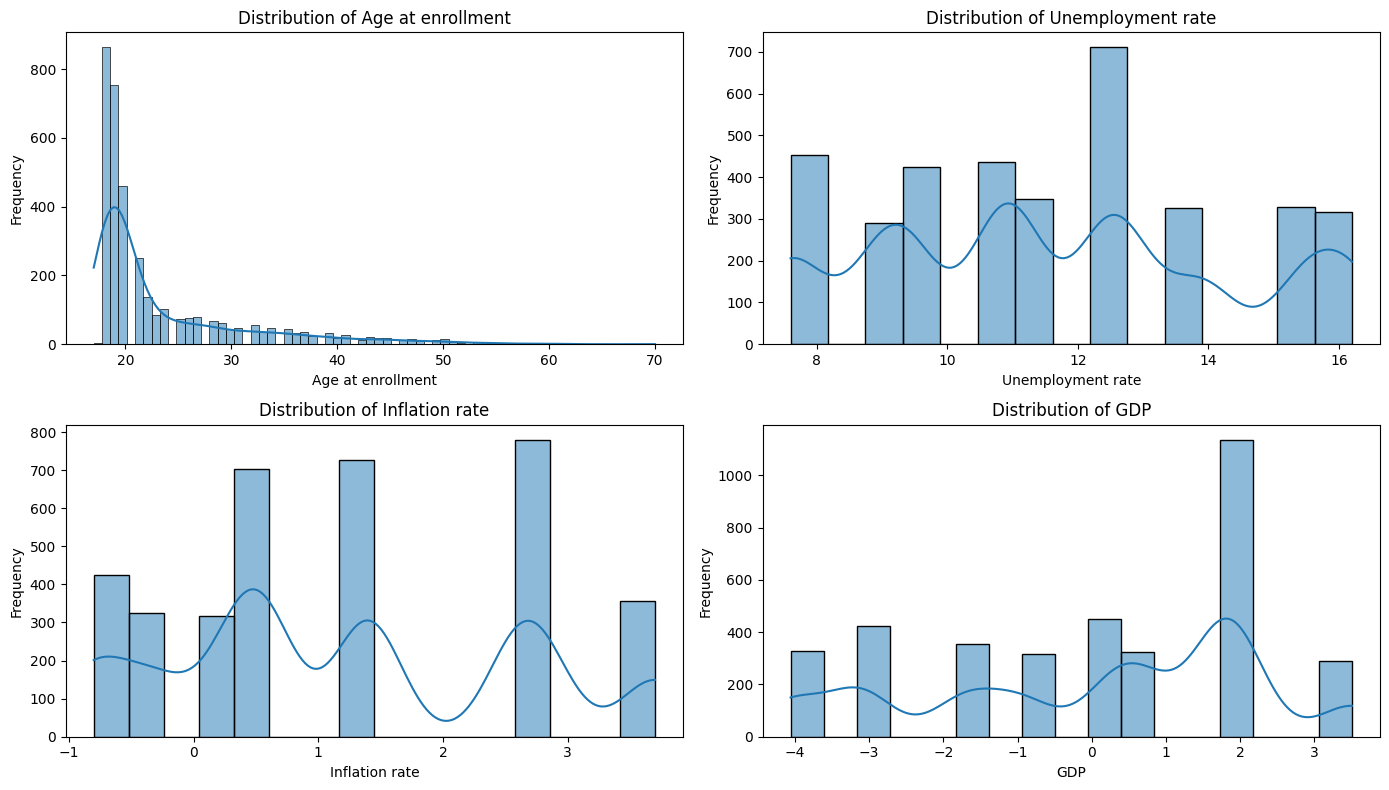

In [255]:
n_cols = 2
n_rows = int(np.ceil(len(continuous_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))

axes = axes.flatten()

for i, col in enumerate(continuous_features):
    sns.histplot(
        data=df_binary,
        x=col,
        kde=True,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

#### Continuous Feature based on Target

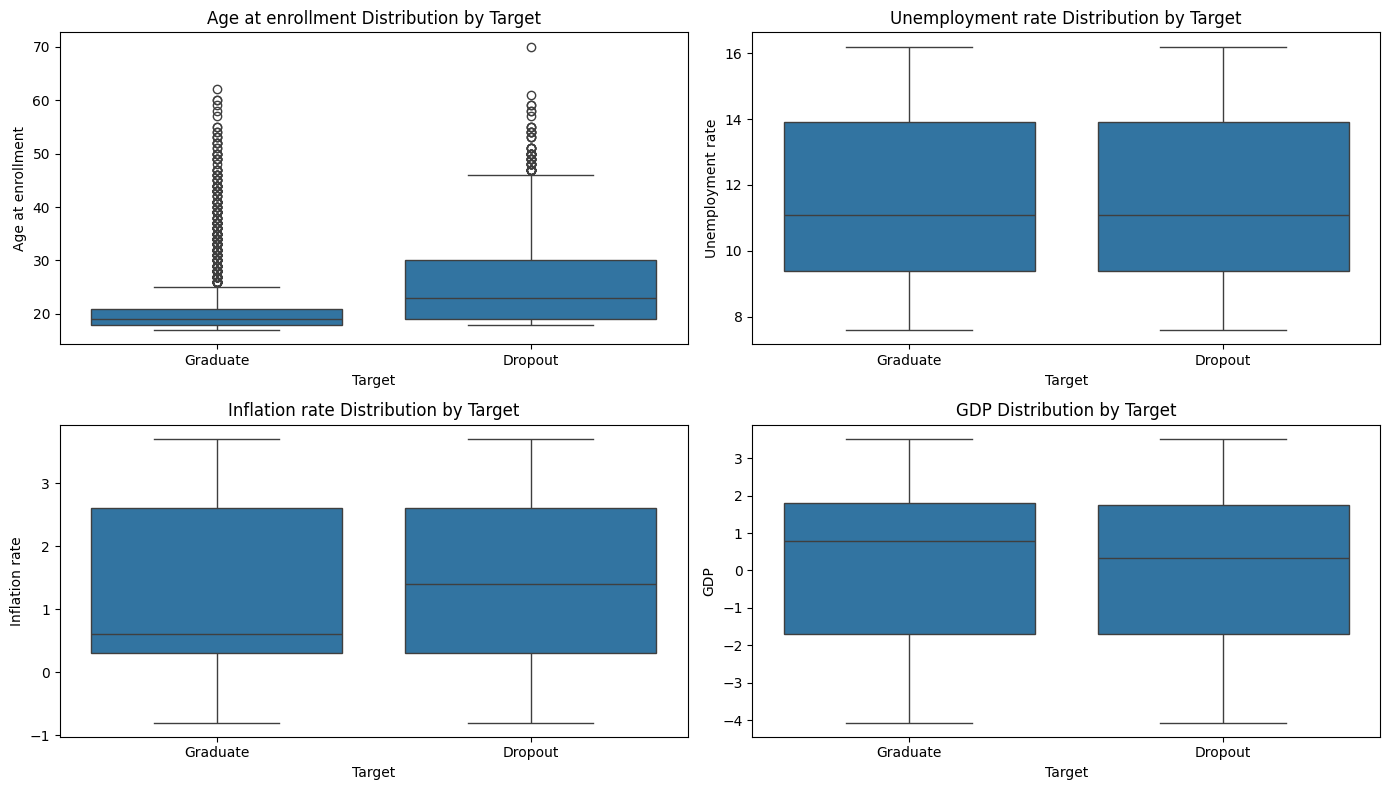

In [256]:
n_cols = 2
n_rows = int(np.ceil(len(continuous_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))

axes = axes.flatten()

for i, col in enumerate(continuous_features):
    sns.boxplot(
        data=df_binary,
        x="Target",
        y=col,
        order=["Graduate", "Dropout"],
        ax=axes[i]
    )
    
    axes[i].set_title(f"{col} Distribution by Target")
    axes[i].set_xlabel("Target")
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

#### Categorical Feature Countplot

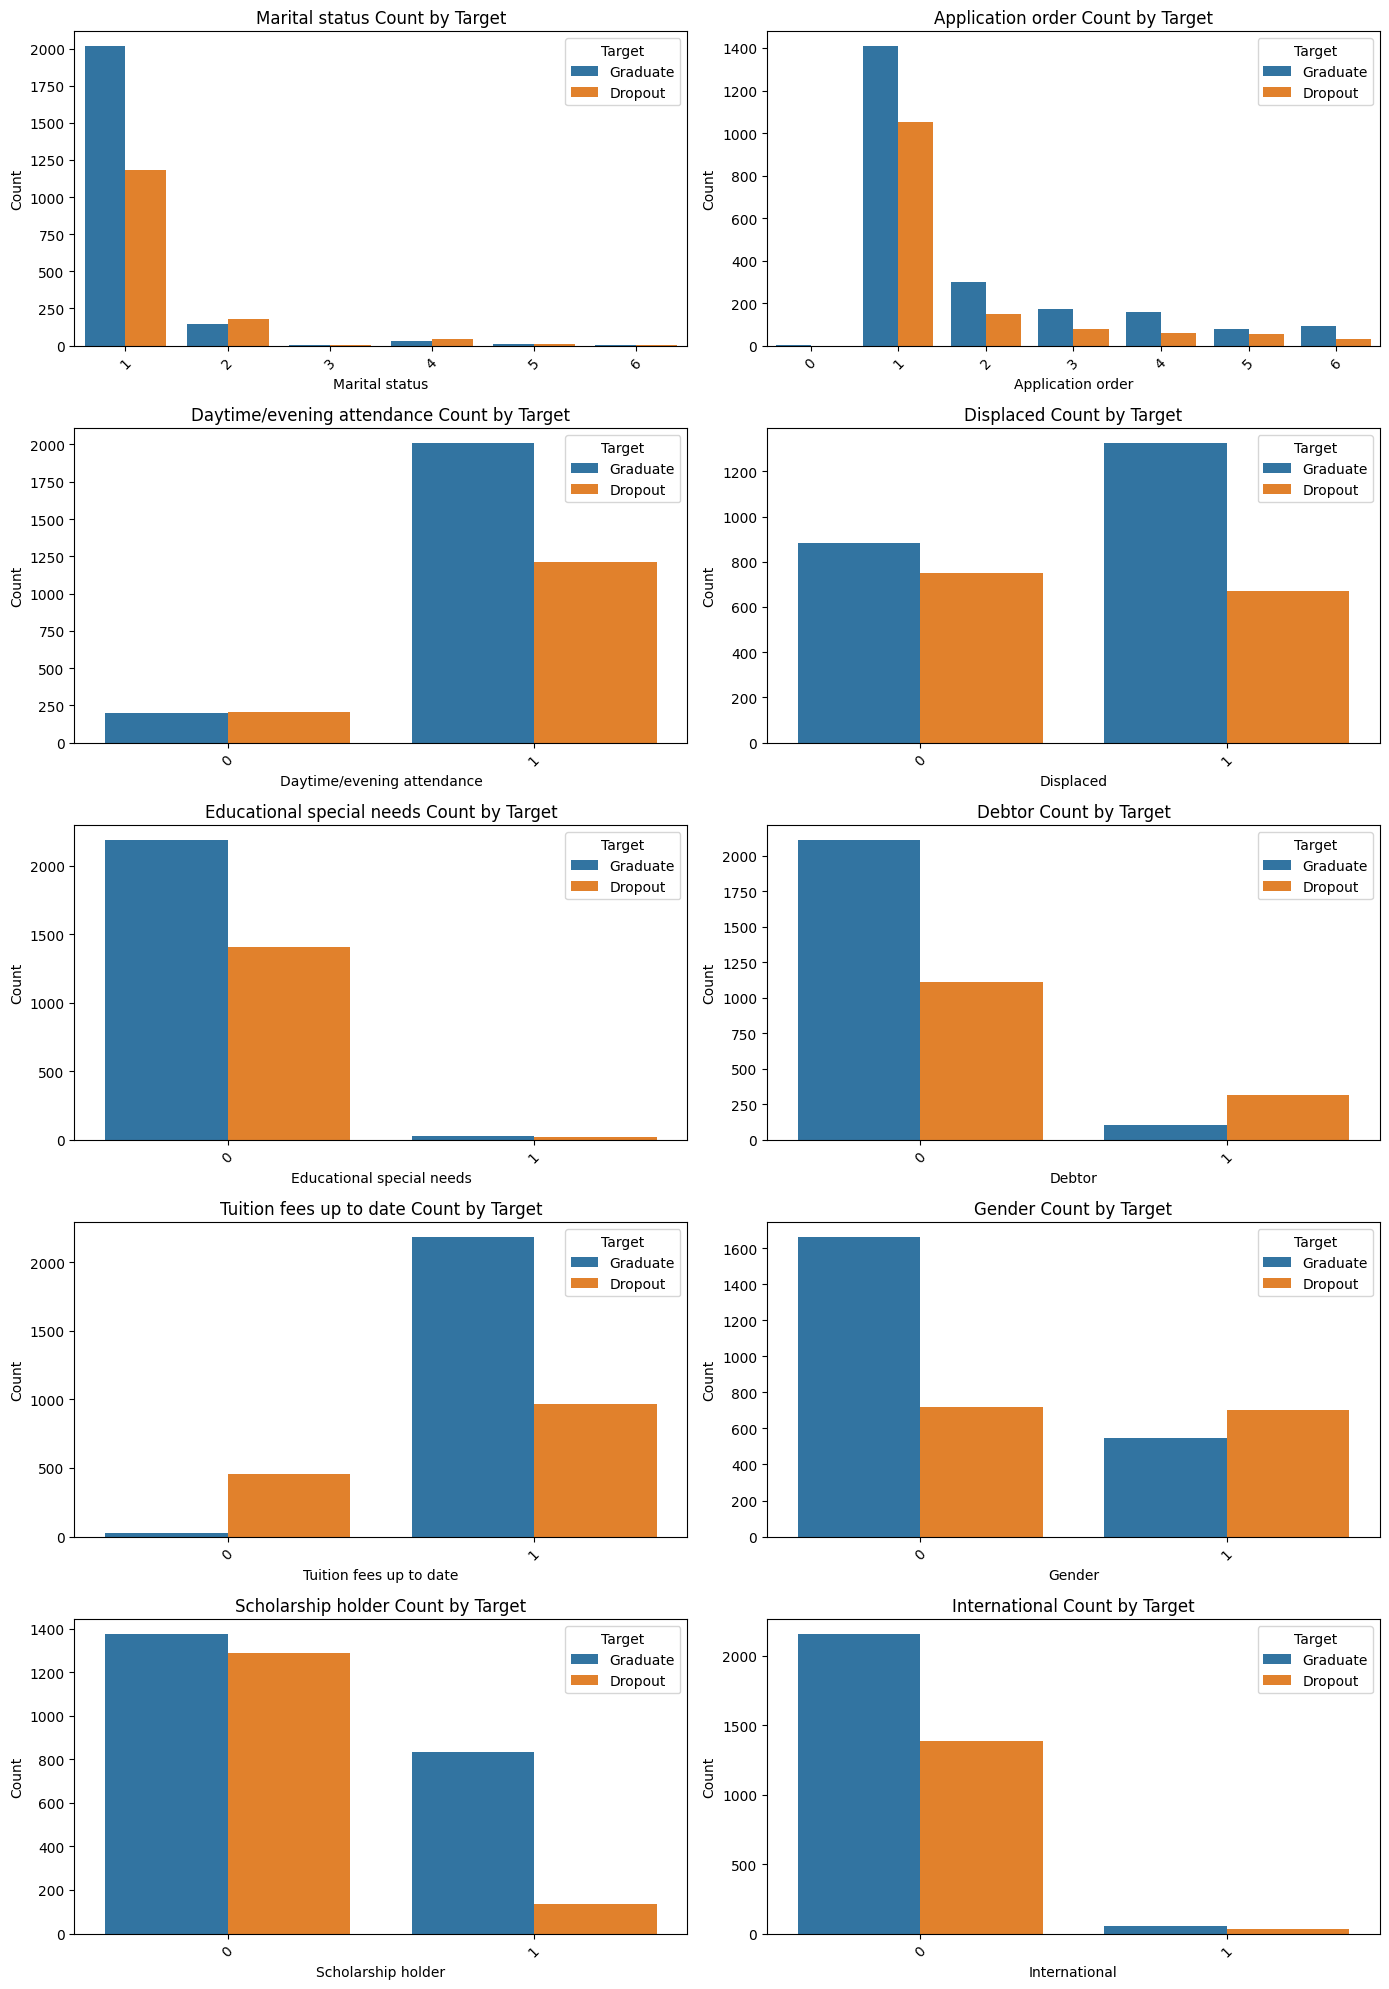

In [257]:
n_cols = 2
n_rows = int(np.ceil(len(selected_categorical_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))

axes = axes.flatten()

for i, col in enumerate(selected_categorical_features):
    sns.countplot(
        data=df_binary,
        x=col,
        hue="Target",
        hue_order=["Graduate", "Dropout"],
        ax=axes[i]
    )
    
    axes[i].set_title(f"{col} Count by Target")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].legend(title="Target")
    axes[i].tick_params(axis="x", rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

#### Continuous Feature Correlations

This section calculates correlation between continuous features.  
The target is temporarily encoded only for correlation analysis and is not used as final preprocessing.

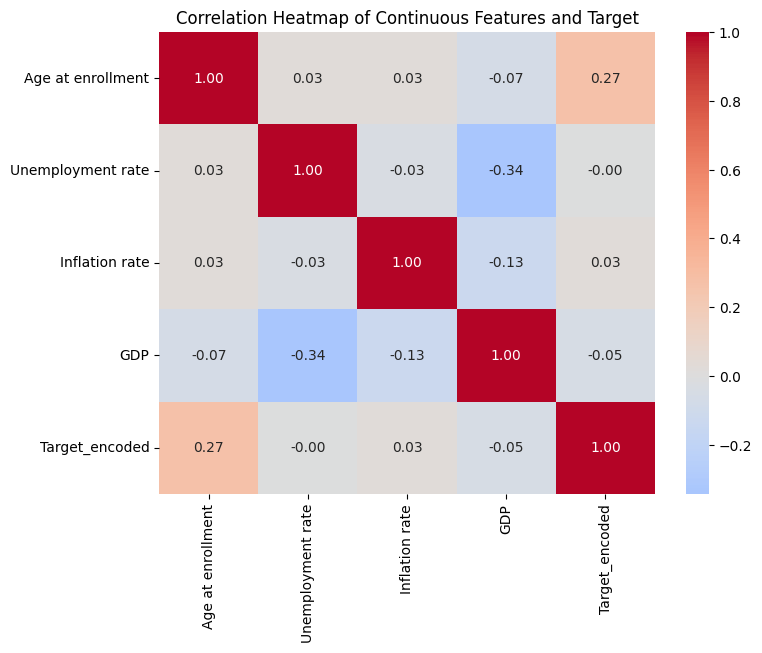

In [258]:
corr_data = df_binary[continuous_features].copy()

corr_data["Target_encoded"] = df_binary["Target"].map({
    "Graduate": 0,
    "Dropout": 1
})

continuous_corr = corr_data.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    continuous_corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Heatmap of Continuous Features and Target")
plt.show()

# EDA Findings

Based on the exploratory data analysis:

- The raw dataset contains 4424 records and 35 columns.
- The raw dataset does not contain missing values or duplicate rows.
- Academic-related features are excluded to align the analysis with the early non-academic prediction objective.
- Enrolled records are removed because this project focuses on binary classification between Graduate and Dropout.
- After filtering, the EDA dataset contains 3630 records and 23 columns.
- The filtered EDA dataset contains 4 duplicated rows after academic-related features are removed.
- Graduate is the majority class, while Dropout is the minority class.
- The target distribution indicates moderate class imbalance, so accuracy should not be used as the only evaluation metric.
- Continuous features are analyzed using descriptive statistics, histograms, boxplots, and correlation heatmap.
- Categorical-like features are analyzed using cross-tabulation and countplot.
- The next stage is preprocessing, where duplicate handling, target encoding, categorical encoding, train-test split, and model preparation will be performed.